In [1]:
import os
import numpy as np
import cv2
from tqdm import tqdm
import tifffile as tiff
import imageio.v3 as iio
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms
from PIL import Image

In [10]:
SEMANTIC_COLORS = np.array([
    [0,   0,   0,   0],    # 0: Background
    [0,  40, 255, 255],    # 1: Cell
    [0, 212, 255, 255],    # 2: Mitochondrion
    [124, 255, 121, 255],    # 3: Alpha granule
    [255, 229,   0, 255],    # 4: Canalicular vessel
    [255,  70,   0, 255],    # 5: Dense granule body
    [127,   0,  127, 255],    # 6: Dense granule core
], dtype=np.uint8)

platelet_em_index_to_class = {
    2: 'mitochondrion',
    3: 'alpha granule',
    4: 'canalicular vessel',
    #5: 'dense granule',
    #6: 'dense granule core'
}

# directory of images and labels-semantic, TaskXX will be generated into here
DATA_DIR = '../data/EPFL_mitochondria'
OUTPUT_BASE = '../data/EPFL_mitochondria'

In [3]:
def get_nnunet_normalization_stats(train_data):
    """
    Calculates stats following the nnU-Net methodology for non-CT images.
    """
    # 1. Clipping outliers (0.5% and 99.5%)
    lower_bound = np.percentile(train_data, 0.5)
    upper_bound = np.percentile(train_data, 99.5)

    # Use a copy for stat calculation to avoid modifying original
    clipped_train = np.clip(train_data, lower_bound, upper_bound)

    # 2. Calculate mean and std of clipped data
    mean_val = clipped_train.mean()
    std_val = clipped_train.std()

    return lower_bound, upper_bound, mean_val, std_val


def apply_normalization(volume, lower, upper, mean, std):
    """
    Applies the calculated stats to any volume.
    """
    # Clip based on training bounds
    v_clipped = np.clip(volume, lower, upper)
    # Z-score normalization
    # Add epsilon to avoid div by zero
    v_norm = (v_clipped - mean) / (std + 1e-8)
    return v_norm

In [4]:
im1 = tiff.imread(f'{DATA_DIR}/training.tif')
im2 = tiff.imread(f'{DATA_DIR}/testing.tif')

lab1 = tiff.imread(f'{DATA_DIR}/training_groundtruth.tif')
lab2 = tiff.imread(f'{DATA_DIR}/testing_groundtruth.tif')

train_slices = im1
val_slices = np.vstack([im2[:82]])
test_slices = np.vstack([im2[82:]])

train_labels = lab1
val_labels = np.vstack([lab2[:82]])
test_labels = np.vstack([lab2[82:]])

In [9]:
val_labels.shape

(82, 768, 1024)

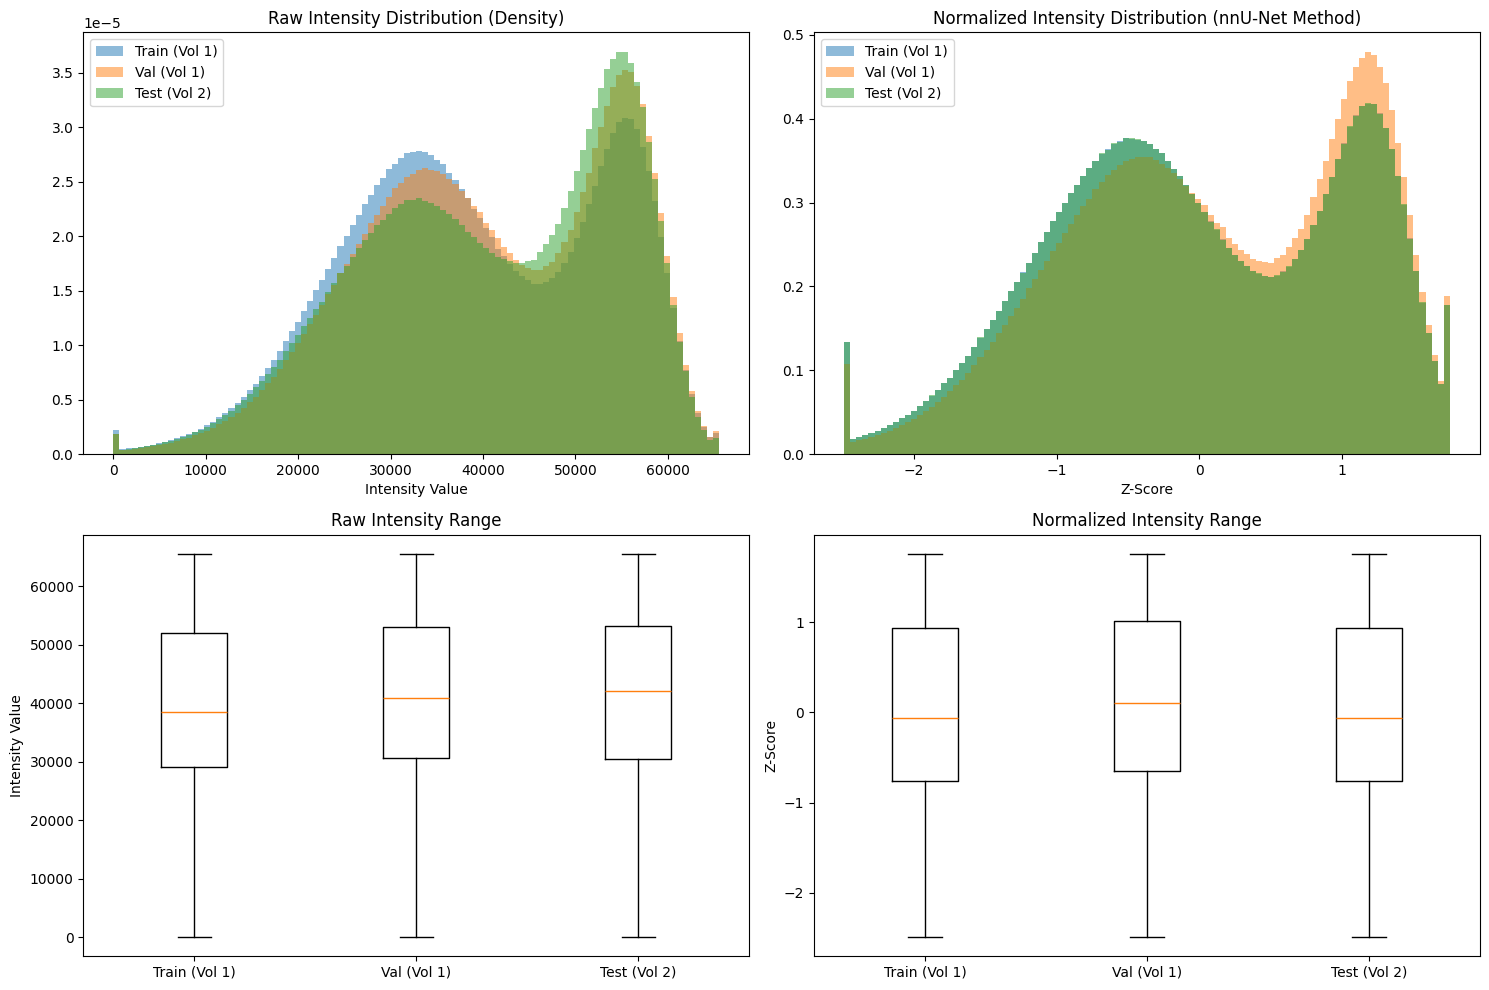

In [ ]:
print("Performing Histogram Matching...")

test_matched = match_histograms(test_slices, train_slices)

lower, upper, mean, std = get_nnunet_normalization_stats(train_slices)

# Apply to all sets
X_train = apply_normalization(train_slices, lower, upper, mean, std)
X_val = apply_normalization(val_slices, lower, upper, mean, std)
X_test = apply_normalization(test_matched, lower, upper, mean, std)

print(f"Stats calculated: Mean={mean:.2f}, Std={std:.2f}")
print(f"Clipping Range: [{lower:.2f}, {upper:.2f}]")
print(f"X_test range after norm: {X_test.min():.2f} to {X_test.max():.2f}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['Train (Vol 1)', 'Val (Vol 1)', 'Test (Vol 2)']

# Plot 1: Raw Histogram
axes[0, 0].hist(train_slices.flatten(), bins=100, color=colors[0],
                alpha=0.5, label=labels[0], density=True)
axes[0, 0].hist(val_slices.flatten(), bins=100, color=colors[1],
                alpha=0.5, label=labels[1], density=True)
axes[0, 0].hist(test_slices.flatten(), bins=100, color=colors[2],
                alpha=0.5, label=labels[2], density=True)
axes[0, 0].set_title('Raw Intensity Distribution (Density)')
axes[0, 0].set_xlabel('Intensity Value')
axes[0, 0].legend()

# Plot 2: Normalized Histogram
axes[0, 1].hist(X_train.flatten(), bins=100, color=colors[0],
                alpha=0.5, label=labels[0], density=True)
axes[0, 1].hist(X_val.flatten(), bins=100, color=colors[1],
                alpha=0.5, label=labels[1], density=True)
axes[0, 1].hist(X_test.flatten(), bins=100, color=colors[2],
                alpha=0.5, label=labels[2], density=True)
axes[0, 1].set_title('Normalized Intensity Distribution (nnU-Net Method)')
axes[0, 1].set_xlabel('Z-Score')
axes[0, 1].legend()

# Plot 3: Boxplot Raw
axes[1, 0].boxplot([train_slices.flatten(), val_slices.flatten(),
                   test_slices.flatten()], tick_labels=labels)
axes[1, 0].set_title('Raw Intensity Range')
axes[1, 0].set_ylabel('Intensity Value')

# Plot 4: Boxplot Normalized
axes[1, 1].boxplot([X_train.flatten(), X_val.flatten(),
                   X_test.flatten()], tick_labels=labels)
axes[1, 1].set_title('Normalized Intensity Range')
axes[1, 1].set_ylabel('Z-Score')

plt.tight_layout()

In [5]:
def get_binary_mask(label_tile, class_idx):
    """Extracts a binary mask, handling potential channel mismatches."""
    target_color = SEMANTIC_COLORS[class_idx]

    # Check if the tile and target have the same number of channels
    n_channels_tile = label_tile.shape[-1]

    if n_channels_tile == 4:
        # If tile is RGBA, we match only the first 3 channels (RGB)
        # to avoid Alpha channel discrepancies
        mask = np.all(label_tile[:, :, :3] == target_color[:3], axis=-1)
    else:
        # If tile is RGB, match against RGB
        mask = np.all(label_tile == target_color[:3], axis=-1)

    return (mask * 255).astype(np.uint8)

In [14]:
splits = {
    'train': (train_slices, train_labels),
    'val': (val_slices, val_labels),
    'test': (test_slices, test_labels),
}

In [15]:
for split, files in splits.items():
    img_stack, lbl_stack = files[0], files[1]
    assert img_stack.shape[0] == lbl_stack.shape[0]
    os.makedirs(os.path.join(OUTPUT_BASE, split, 'images'), exist_ok=True)
    for class_name in ['mitochondria']:
        os.makedirs(os.path.join(OUTPUT_BASE, split,
                    'labels', class_name), exist_ok=True)

    i = 0
    for img_slice, lbl_slice in tqdm(zip(img_stack, lbl_stack), desc=f'generating {split} files'):
        if img_slice.dtype != np.uint8:
            # Linear normalization to 0-255 range
            img_min = img_slice.min()
            img_max = img_slice.max()
            if img_max > img_min:
                img_slice = (img_slice - img_min) / (img_max - img_min) * 255
            img_slice = img_slice.astype(np.uint8)

        tile_id = f"{split}slice_{i}.png"

        # Save Image
        cv2.imwrite(os.path.join(OUTPUT_BASE, split, 'images', tile_id), img_slice)
        cv2.imwrite(os.path.join(OUTPUT_BASE, split, 'labels', 'mitochondria', tile_id), lbl_slice)
        i += 1

print(f"Dataset generation complete.")

generating train files: 165it [00:02, 70.13it/s]
generating val files: 82it [00:01, 74.17it/s]
generating test files: 83it [00:01, 74.56it/s]

Dataset generation complete.


In [25]:
import numpy as np
import pandas as pd
import imageio.v3 as iio
from scipy import ndimage
from tqdm import tqdm

PIXEL_AREA_MM2 = 1e-10
MIN_INSTANCE_AREA_MM2 = 0.0  # Set a threshold if you want to filter noise

LBL_PATH = '../data/platelet-em/labels-semantic/50-semantic.tif'

def extract_2d_metrics(label_stack, class_indices, class_mapping):
    all_records = []

    # Iterate through each slice (Z)
    for z in tqdm(range(label_stack.shape[0]), desc="Analyzing Slices"):
        slice_data = label_stack[z]

        for idx, class_name in class_mapping.items():
            # Get binary mask for this specific class
            # Using the target color matching logic from previous steps
            target_color = SEMANTIC_COLORS[idx]
            mask = np.all(slice_data == target_color, axis=-1)

            if not np.any(mask):
                continue

            # Connected Components in 2D (8-connectivity)
            labeled, n_instances = ndimage.label(
                mask, structure=np.ones((3, 3)))

            instance_areas = []
            for i in range(1, n_instances + 1):
                px_count = np.sum(labeled == i)
                area_mm2 = px_count * PIXEL_AREA_MM2

                if area_mm2 >= MIN_INSTANCE_AREA_MM2:
                    instance_areas.append(area_mm2)

            if not instance_areas:
                continue

            instance_areas = np.array(instance_areas)

            # Generate metrics for this class on THIS specific slice
            stats = {
                "slice_z": z,
                "class": class_name,
                "n_instances": len(instance_areas),
                "total_area_mm2": instance_areas.sum(),
                "mean_area_mm2": instance_areas.mean(),
                "median_area_mm2": np.median(instance_areas),
                "max_area_mm2": instance_areas.max(),
                "min_area_mm2": instance_areas.min(),
                # Store raw areas if you want to do distribution plots later
                "all_areas": instance_areas.tolist()
            }
            all_records.append(stats)

    return pd.DataFrame(all_records)


# --- Execution ---
print("Loading semantic label stack...")
lbl_stack = iio.imread(LBL_PATH)

df_metrics = extract_2d_metrics(
    lbl_stack, platelet_em_index_to_class.keys(), platelet_em_index_to_class)

# --- Summary Analytics ---
summary = df_metrics.groupby('class').agg({
    'n_instances': 'sum',
    'total_area_mm2': 'mean'  # Average area covered per slice
}).rename(columns={'total_area_mm2': 'avg_area_per_slice_mm2'})

print("\nDataset Summary per Class:")
print(summary)

Loading semantic label stack...


Analyzing Slices: 100%|██████████| 50/50 [00:05<00:00,  8.46it/s]



Dataset Summary per Class:
                    n_instances  avg_area_per_slice_mm2
class                                                  
alpha granule              1363            2.972710e-06
canalicular vessel         2789            1.995720e-06
dense granule               134            1.586083e-07
mitochondrion               224            3.939260e-07


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def generate_class_summaries(df_metrics):
    summaries = {}

    # We analyze each class individually
    for class_name in df_metrics['class'].unique():
        class_df = df_metrics[df_metrics['class'] == class_name]

        # 'instances_df' equivalent: flattening the 'all_areas' list
        all_areas = np.concatenate(class_df['all_areas'].values)

        # Calculate 'largest_fraction' for each slice
        # (Area of largest instance in slice / Total area of class in slice)
        largest_fractions = class_df['max_area_mm2'] / \
            class_df['total_area_mm2']

        summary = {
            "n_slices": len(class_df),
            "median_instances_per_slice": class_df["n_instances"].median(),
            "iqr_instances": (
                class_df["n_instances"].quantile(0.25),
                class_df["n_instances"].quantile(0.75),
            ),
            "mean_instance_area_mm2": all_areas.mean(),
            "std_instance_area_mm2": all_areas.std(),
            "p95_over_p50": (
                np.percentile(all_areas, 95) / np.percentile(all_areas, 50)
            ),
            "mean_largest_fraction_per_slice": largest_fractions.mean(),
        }
        summaries[class_name] = summary

    return pd.DataFrame.from_dict(summaries, orient="index").T


summary_df = generate_class_summaries(df_metrics)
print(summary_df)

                                mitochondrion  alpha granule  \
n_slices                                   50             50   
median_instances_per_slice                5.0           27.0   
iqr_instances                      (3.0, 5.0)  (25.25, 29.0)   
mean_instance_area_mm2                    0.0            0.0   
std_instance_area_mm2                     0.0            0.0   
p95_over_p50                         2.039339       2.998802   
mean_largest_fraction_per_slice      0.447612       0.116289   

                                canalicular vessel dense granule  
n_slices                                        50            48  
median_instances_per_slice                    57.0           2.0  
iqr_instances                        (43.5, 66.75)   (1.0, 3.25)  
mean_instance_area_mm2                         0.0           0.0  
std_instance_area_mm2                          0.0           0.0  
p95_over_p50                              3.544151      2.332512  
mean_largest_fract

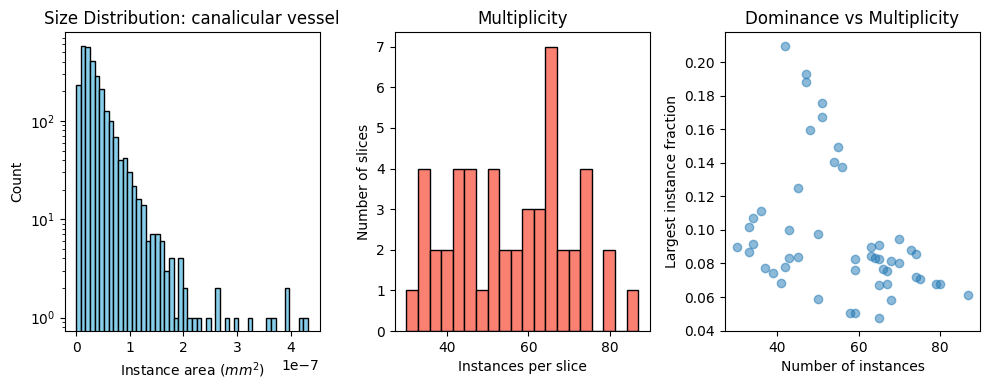

In [31]:
# Choose a class to visualize (e.g., 'mitochondrion')
target_class = 'canalicular vessel'
class_df = df_metrics[df_metrics['class'] == target_class]
all_areas = np.concatenate(class_df['all_areas'].values)

# 1. Instance Area Distribution (Log Scale)
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.hist(all_areas, bins=50, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.xlabel("Instance area ($mm^2$)")
plt.ylabel("Count")
plt.title(f"Size Distribution: {target_class}")

# 2. Multiplicity per Slice
plt.subplot(1, 3, 2)
plt.hist(class_df["n_instances"], bins=20, color='salmon', edgecolor='black')
plt.xlabel("Instances per slice")
plt.ylabel("Number of slices")
plt.title("Multiplicity")

# 3. Dominance vs Multiplicity
plt.subplot(1, 3, 3)
largest_fractions = class_df["max_area_mm2"] / class_df["total_area_mm2"]
plt.scatter(class_df["n_instances"], largest_fractions, alpha=0.5)
plt.xlabel("Number of instances")
plt.ylabel("Largest instance fraction")
plt.title("Dominance vs Multiplicity")

plt.tight_layout()
plt.show()